In [47]:
#Load modules
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


In [48]:
#pre-process the data
df = pd.read_csv("insurance.csv")

#select features
y= df['charges']
X = df.drop('charges',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

In [49]:
#Make the prediction
regressor = RandomForestRegressor(n_estimators=100, random_state=69)
RFscores = cross_val_score(regressor, X, y, cv=5,
                            scoring='neg_mean_absolute_error')
MAE = mean(absolute(RFscores))
print('the MAE is: %.2f'% MAE)



the MAE is: 2702.86


In [50]:
#Calculate Gini importance
regressor = RandomForestRegressor(n_estimators=100, random_state=69) #Define the model
regressor.fit(X,y) #Fit the data to the random forest model
feature_importances = regressor.feature_importances_ #get the GINI importances

importance_df = pd.DataFrame({ #create a dataframe shat shows the importance for each feature
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False) #sort the data from high to low

print(importance_df) #print the result

            Feature  Importance
5        smoker_yes    0.621275
1               bmi    0.206497
0               age    0.127838
2          children    0.018443
6  region_northwest    0.005964
4          sex_male    0.005669
3             death    0.005314
7  region_southeast    0.004957
8  region_southwest    0.004042


In [51]:
#Hyperparameter Tuning (1)
#pre-process the data
df = pd.read_csv("insurance.csv")

#With logistic regression
y= df['death']
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

In [52]:
#Hyperparameter Tuning (2)
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter tuning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 250, step=10),
        'max_depth': trial.suggest_int('max_depth', 10, 250, step=10),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 30, step=1),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'random_state': 69
    }
    rf = RandomForestClassifier(**params)
    score = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=69))
study.optimize(objective, n_trials=100, n_jobs=-1)  # search across 100 different combinations

study.best_params

[I 2026-10-02 14:19:50,847] A new study created in memory with name: no-name-df06cc0e-b586-42f1-9db3-30c9046a96c5
[I 2026-10-02 14:19:51,413] Trial 1 finished with value: -0.16816479400749065 and parameters: {'n_estimators': 80, 'max_depth': 250, 'min_samples_split': 18, 'max_features': None}. Best is trial 1 with value: -0.16816479400749065.
[I 2026-10-02 14:19:52,210] Trial 5 finished with value: -0.16441947565543072 and parameters: {'n_estimators': 80, 'max_depth': 90, 'min_samples_split': 11, 'max_features': 'log2'}. Best is trial 5 with value: -0.16441947565543072.
[I 2026-10-02 14:19:52,297] Trial 2 finished with value: -0.15992788864665436 and parameters: {'n_estimators': 180, 'max_depth': 170, 'min_samples_split': 27, 'max_features': 'log2'}. Best is trial 2 with value: -0.15992788864665436.
[I 2026-10-02 14:19:52,663] Trial 0 finished with value: -0.16815640896640394 and parameters: {'n_estimators': 210, 'max_depth': 220, 'min_samples_split': 16, 'max_features': None}. Best is

{'n_estimators': 190,
 'max_depth': 210,
 'min_samples_split': 20,
 'max_features': 'sqrt'}

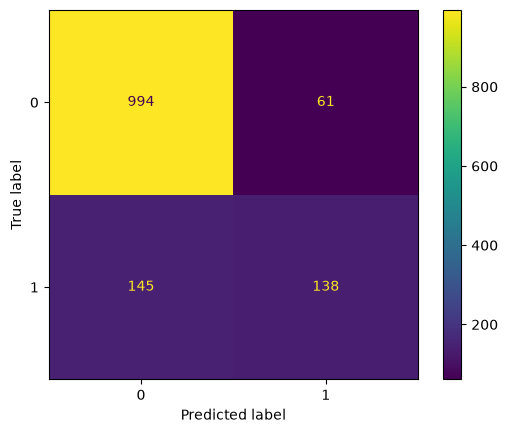

Accuracy: 0.8460388639760837


In [53]:
#Run the optimized model
regressor = RandomForestClassifier(**study.best_params,
                                      random_state=69) 

y_pred = cross_val_predict(regressor, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

accuracy = (cm.diagonal().sum()) / cm.sum() #calculate accuracy
print("Accuracy:",accuracy)

In [1]:
#Prediction with XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make the prediction
xgb = XGBClassifier(n_estimators=100, random_state=69, eval_metric='logloss')
y_pred = cross_val_predict(xgb, X, y, cv=5)  # make the predictions
cm = confusion_matrix(y, y_pred)  # create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # create the graph
disp.plot()  # plot the graph
plt.show()  # show the graph
accuracy = (cm.diagonal().sum()) / cm.sum()  # calculate accuracy
print("Accuracy:", accuracy)  # print accuracy

ImportError: DLL load failed while importing _random: Dit bestand is geblokkeerd door een beleid voor toepassingsbeheer.

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 69,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

c:\Users\Tijmen\anaconda3\envs\env2526\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-02 14:39:24,620] A new study created in memory with name: no-name-75c9fc5f-ff47-465f-8159-2882561ed799
[I 2026-07-02 14:39:25,334] Trial 0 finished with value: 0.8056962379115656 and parameters: {'n_estimators': 165, 'max_depth': 7, 'learning_rate': 0.25488423993920595, 'subsample': 0.6795633512966371, 'colsample_bytree': 0.8719245540066537, 'min_child_weight': 2}. Best is trial 0 with value: 0.8056962379115656.
[I 2026-07-02 14:39:26,639] Trial 1 finished with value: 0.8243585443568673 and parameters: {'n_estimators': 485, 'max_depth': 8, 'learning_rate': 0.04748901847254695, 'subsample': 0.5236793925010714, 'colsample_bytree': 0.5924772053323033, 'min_child_weight': 2}. Best is trial 1 with value: 0.8243585443568673

Best params: {'n_estimators': 115, 'max_depth': 9, 'learning_rate': 0.020645339850686156, 'subsample': 0.6834325710726653, 'colsample_bytree': 0.6864426176892111, 'min_child_weight': 7}
Best accuracy: 0.8490273352339427
